In [40]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)
x = np.sort(rng.uniform(0, 1, 150))
X = x.reshape(-1, 1)
xx = np.linspace(0, 1, 600)
XX = xx.reshape(-1, 1)

In [41]:
# Kasus A: pola halus dan global
f_smooth = lambda x: np.sin(2*np.pi*x) + 0.35*np.cos(6*np.pi*x) + 0.5*x
y_smooth = f_smooth(x) + rng.normal(0, 0.15, len(x))
# Kasus B: pola threshold / bertangga
f_step = lambda x: np.piecewise(
    x,
    [x < 0.25, (x >= 0.25) & (x < 0.55), (x >= 0.55) & (x < 0.8), x >= 0.8],
    [0.7, -0.4, 1.2, 0.2]
) + 0.15*x
y_step = f_step(x) + rng.normal(0, 0.10, len(x))
# Kasus C: pola lokal dengan puncak sempit
f_local = lambda x: 0.5*x + 1.4*np.exp(-120*(x-0.32)**2)- 1.2*np.exp(-160*(x-0.72)**2)
y_local = f_local(x) + rng.normal(0, 0.10, len(x))

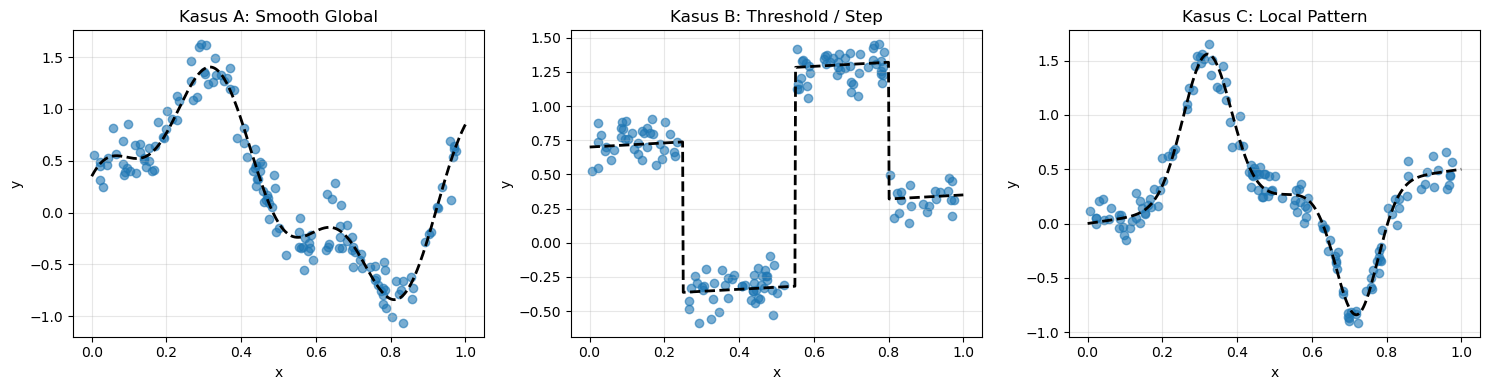

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(x, y_smooth, alpha=0.6)
axes[0].plot(xx, f_smooth(xx), 'k--', linewidth=2)
axes[0].set_title('Kasus A: Smooth Global')
axes[1].scatter(x, y_step, alpha=0.6)
axes[1].plot(xx, f_step(xx), 'k--', linewidth=2)
axes[1].set_title('Kasus B: Threshold / Step')
axes[2].scatter(x, y_local, alpha=0.6)
axes[2].plot(xx, f_local(xx), 'k--', linewidth=2)
axes[2].set_title('Kasus C: Local Pattern')
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
plt.tight_layout()
plt.show()

In [50]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly_model = make_pipeline(
    PolynomialFeatures(degree=1, include_bias=False),
    LinearRegression()
)

In [51]:
from sklearn.preprocessing import KBinsDiscretizer
step_model = make_pipeline(
    KBinsDiscretizer(n_bins=8, encode='onehot-dense', strategy='uniform'),
    LinearRegression()
)

In [52]:
from sklearn.base import BaseEstimator, TransformerMixin
class RBFFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, centers, gamma=90):
        self.centers = np.asarray(centers)
        self.gamma = gamma
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = np.asarray(X).reshape(-1, 1)
        return np.exp(-self.gamma * (X- self.centers)**2)
centers = np.linspace(0, 1, 12).reshape(1,-1)
rbf_model = make_pipeline(
    RBFFeatures(centers=centers, gamma=90),
    LinearRegression()
)

In [45]:
def fit_and_predict(model, X, y, XX):
    model.fit(X, y)
    return model.predict(XX)
# contoh untuk kasus smooth
yhat_poly_smooth = fit_and_predict(poly_model, X, y_smooth, XX)
yhat_step_smooth = fit_and_predict(step_model, X, y_smooth, XX)
yhat_rbf_smooth = fit_and_predict(rbf_model, X, y_smooth, XX)

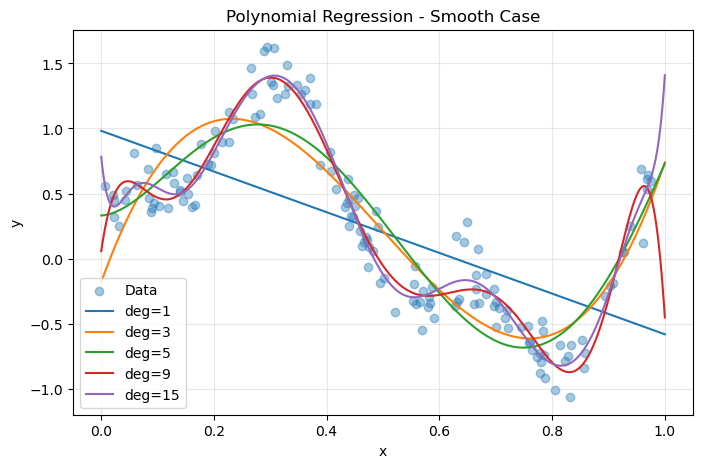

In [49]:
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# function buat model polynomial
def make_poly_model(degree):
    return make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

# function fit + predict
def fit_and_predict(model, X, y, XX):
    model.fit(X, y)
    return model.predict(XX)

# =========================
# 🔥 EXPERIMENT DEGREE
# =========================

degrees = [1, 3, 5, 9, 15]

plt.figure(figsize=(8,5))

# plot data asli
plt.scatter(x, y_smooth, alpha=0.4, label="Data")

# loop berbagai degree
for d in degrees:
    model = make_poly_model(d)
    yhat = fit_and_predict(model, X, y_smooth, XX)
    plt.plot(xx, yhat, label=f"deg={d}")

plt.legend()
plt.title("Polynomial Regression - Smooth Case")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()

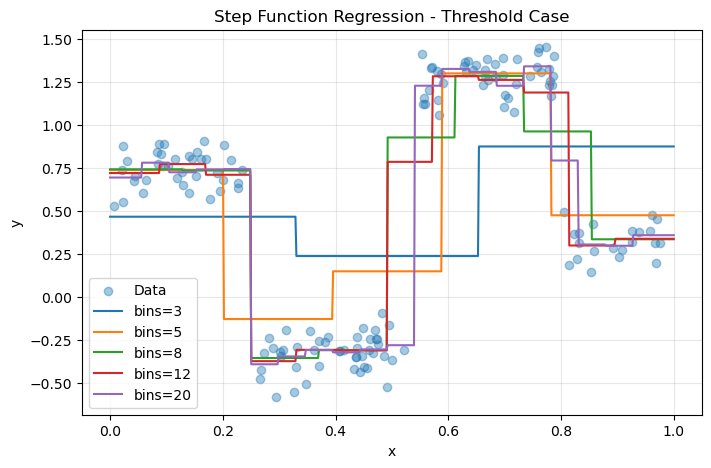

In [56]:
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.linear_model import LinearRegression

# function buat model step
def make_step_model(n_bins):
    return make_pipeline(
        KBinsDiscretizer(n_bins=n_bins, encode='onehot-dense', strategy='uniform'),
        LinearRegression()
    )

# function fit + predict
def fit_and_predict(model, X, y, XX):
    model.fit(X, y)
    return model.predict(XX)

# =========================
# 🔥 EXPERIMENT BINS
# =========================

bins_list = [3, 5, 8, 12, 20]

plt.figure(figsize=(8,5))

# plot data asli (coba pakai kasus B biar cocok)
plt.scatter(x, y_step, alpha=0.4, label="Data")

# loop berbagai jumlah bins
for b in bins_list:
    model = make_step_model(b)
    yhat = fit_and_predict(model, X, y_step, XX)
    plt.plot(xx, yhat, label=f"bins={b}")

plt.legend()
plt.title("Step Function Regression - Threshold Case")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()

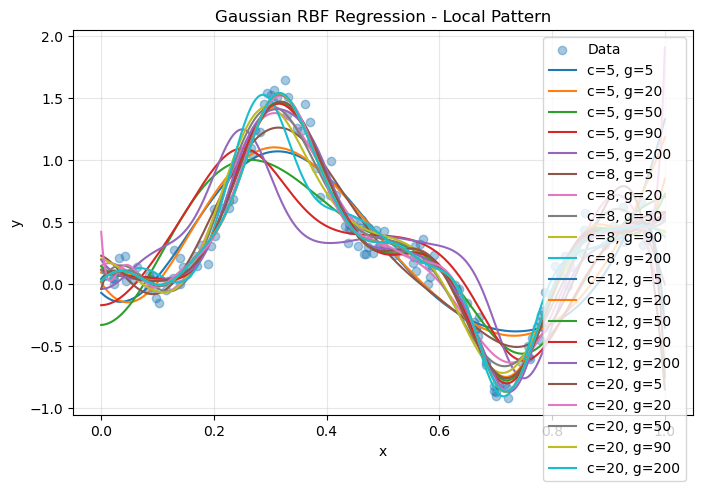

In [63]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, TransformerMixin

# =========================
# 🔥 RBF Feature Class
# =========================
class RBFFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, centers, gamma=1.0):
        self.centers = np.asarray(centers)
        self.gamma = gamma

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.asarray(X).reshape(-1, 1)
        return np.exp(-self.gamma * (X - self.centers)**2)

# =========================
# 🔥 Model Builder
# =========================
def make_rbf_model(n_centers, gamma):
    centers = np.linspace(0, 1, n_centers).reshape(1, -1)
    return make_pipeline(
        RBFFeatures(centers=centers, gamma=gamma),
        LinearRegression()
    )

# =========================
# Fit + Predict
# =========================
def fit_and_predict(model, X, y, XX):
    model.fit(X, y)
    return model.predict(XX)

# =========================
# 🔥 EXPERIMENT RBF
# =========================

configs = [
    (5, 5),
    (5, 20),
    (5, 50),
    (5, 90),
    (5, 200),
    (8, 5),
    (8, 20),
    (8, 50),
    (8, 90),
    (8, 200),
    (12, 5),
    (12, 20),
    (12, 50),
    (12, 90),
    (12, 200),
    (20, 5),
    (20, 20),
    (20, 50),
    (20, 90),
    (20, 200)
]

plt.figure(figsize=(8,5))

# pakai kasus C (pola lokal)
plt.scatter(x, y_local, alpha=0.4, label="Data")

for n_centers, gamma in configs:
    model = make_rbf_model(n_centers, gamma)
    yhat = fit_and_predict(model, X, y_local, XX)
    plt.plot(xx, yhat, label=f"c={n_centers}, g={gamma}")

plt.legend()
plt.title("Gaussian RBF Regression - Local Pattern")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()